# Plots for ALBATROS Solar Paper

In [5]:
from __future__ import annotations

import warnings
from pathlib import Path
from typing import Iterable, Optional, Tuple

import cmasher as cmr
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.colors import LinearSegmentedColormap as LSC
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pyproj import CRS, Transformer
from scipy.ndimage import map_coordinates
from scipy.signal import correlate, correlation_lags
from solshade.solar import compute_solar_ephem
from solshade.terrain import load_dem
from solshade.utils import parse_iso_utc

from specscout.core import freq_axis_from_attrs
from specscout.patches import open_cube, read_time_range
from specscout.preprocess import PreprocessPipeline, step_safe_db, step_stokes_i, step_stokes_iquv
from specscout.viz.static import (
    _build_stokes_fractional_quicklook,
    _centered_vlims_for_image,
    _normalize_panel_arg,
    _reject_db_recipe_pipe,
    _time_edges_from_datetimes,
    _vlims_for_image,
    plot_time_range_stokes_fractional,
)

prd = LSC.from_list("pride", cmr.pride(np.linspace(0.03, 0.9, 256)))

plt.rcParams.update(
    {
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "lines.linewidth": 1.2,
        "axes.linewidth": 0.8,
        "savefig.dpi": 300,
        "font.family": "serif",
    }
)

In [2]:
def compute_horizon_profile(
    dem: xr.DataArray,
    point_xy: Tuple[float, float],
    point_crs: Optional[str] = None,
    n_directions: int = 360,
    max_distance: float = 5000.0,
    step: float = 20.0,
) -> xr.DataArray:
    """
    Compute the horizon angle profile at a single geographic location.

    Parameters
    ----------
    dem : xr.DataArray
        2D DEM (y, x) with CRS and affine transform set via rioxarray.
    point_xy : (float, float)
        Input point coordinates as (x, y) in the coordinate system given by
        `point_crs`. If `point_crs` is None, they are assumed to already be
        in the DEM's CRS.
    point_crs : str or None, optional
        EPSG string or WKT of the point coordinates (e.g., "EPSG:4326").
        If None, assumes `point_xy` is in the DEM's CRS.
    n_directions : int, optional
        Number of azimuth samples in [0, 360) deg. Default 360.
    max_distance : float, optional
        Maximum tracing distance [m]. Default 5000.
    step : float, optional
        Ray sampling step [m]. Default 20.

    Returns
    -------
    xr.DataArray
        1D DataArray of horizon angles [deg] with coord `azimuth` (degrees).
        Values are the maximum elevation angle along each azimuthal ray.
        NaN if no valid sample was found along a ray.

    Notes
    -----
    - Azimuth is clockwise from North (0 deg = North, 90 deg = East).
    - Uses bilinear sampling of elevations along each ray.
    """
    if dem.rio.crs is None or dem.rio.transform() is None:
        raise ValueError("DEM must have CRS and affine transform defined.")

    dem_crs = dem.rio.crs
    x_in, y_in = point_xy

    # Reproject point into DEM CRS if needed
    if point_crs is not None:
        transformer = Transformer.from_crs(
            CRS.from_user_input(point_crs),
            dem_crs,
            always_xy=True,
        )
        x_dem, y_dem = transformer.transform(x_in, y_in)
    else:
        x_dem, y_dem = x_in, y_in

    # Map world coords -> pixel indices
    # Affine transform is from pixel -> world; invert to get world -> pixel
    A = dem.rio.transform()
    Ainv = ~A
    col_f, row_f = Ainv * (x_dem, y_dem)
    iy0, ix0 = int(np.round(row_f)), int(np.round(col_f))

    ny, nx = dem.shape
    if not (0 <= iy0 < ny and 0 <= ix0 < nx):
        raise ValueError("Point falls outside DEM extent.")

    # Geometry
    res_x, res_y = A.a, -A.e  # pixel sizes (meters); note sign on e
    azimuths = np.linspace(0.0, 360.0, n_directions, endpoint=False)
    distances = np.arange(0.0, max_distance + step, step)
    ns = len(distances)

    # Rays in pixel units from the seed pixel center
    # y increases downward in array index space
    dx_pix = (np.cos(np.deg2rad(azimuths))[:, None] * distances) / res_x
    dy_pix = (-np.sin(np.deg2rad(azimuths))[:, None] * distances) / res_y

    # Sample coordinates for scipy.map_coordinates expect (rows, cols)
    sample_y = iy0 + dy_pix  # shape (nd, ns)
    sample_x = ix0 + dx_pix  # shape (nd, ns)

    # Stack into (2, nd*ns)
    coords = np.stack([sample_y, sample_x], axis=0).reshape(2, -1)

    elev = dem.values
    elev_profiles = map_coordinates(
        elev,
        coords,
        order=1,
        mode="constant",
        cval=np.nan,
    ).reshape(n_directions, ns)

    elev0 = elev[iy0, ix0]

    # Compute max elevation angle per azimuth (skip distance=0 to avoid div by 0)
    horizon_deg = np.full(n_directions, np.nan, dtype=np.float32)
    with np.errstate(invalid="ignore", divide="ignore"):
        dz = elev_profiles[:, 1:] - elev0
        ang = np.arctan2(dz, distances[1:])  # radians
        # nanmax over distance; if all nan -> keep nan
        horizon_rad = np.nanmax(ang, axis=1)
        horizon_deg[:] = np.degrees(horizon_rad)

    out = xr.DataArray(
        horizon_deg,
        dims=("azimuth",),
        coords={"azimuth": azimuths},
        name="horizon_angle",
        attrs={
            "units": "degrees",
            "max_distance_m": max_distance,
            "step_m": step,
            "n_directions": n_directions,
            "azimuth_meaning": "clockwise from North",
            "point_x_dem_crs": float(x_dem),
            "point_y_dem_crs": float(y_dem),
        },
    )
    # Carry CRS metadata so downstream ops preserve georeferencing context
    out.rio.write_crs(dem_crs, inplace=True)
    return out

In [3]:
gps_coords = {
    "ALB1": [79.417161473, -90.767238685, 187.9577],
    "ALB2": [79.417198047, -90.758739192, 183.0684],
    "ALB3": [79.415409047, -90.772991226, 180.4816],
    "ALB4": [79.388456412, -91.019202963, 25.1938],
    "ALB5": [79.418302573, -90.667395452, 59.6242],
    "ALB6": [79.397984238, -90.799842408, 41.6994],
    "ALB7": [79.411474117, -90.695266129, 31.6314],
    "ALB8": [79.443757694, -90.718202634, 414.9131],
}

dem = load_dem("../../wave-rider/data/dem/mars_extra_large.tif")

n_directions = 360
startutc = "2025-01-01T00:00:00Z"
stoputc = "2026-01-01T00:00:00Z"
timestep = 24 * 60 * 60 / n_directions

solar_profiles = {ant: {} for ant in gps_coords.keys()}

for ant, gps in gps_coords.items():
    lat, lon, _ = gps

    hprof = compute_horizon_profile(
        dem,
        (lon, lat),
        point_crs="EPSG:4326",
        n_directions=n_directions,
        max_distance=2**14,
        step=2**6,
    )

    solar_profiles[ant]["hp"] = hprof

    azimuths = np.linspace(0, n_directions, n_directions, endpoint=False)
    times_utc, alt_deg, az_deg, _, _ = compute_solar_ephem(
        lat=lat,
        lon=lon,
        startutc=parse_iso_utc(startutc),
        stoputc=parse_iso_utc(stoputc),
        timestep=timestep,
        cache_dir=("../data/skyfield"),
    )

    solar_profiles[ant]["azimuths"] = azimuths
    solar_profiles[ant]["times_utc"] = times_utc[:-1].reshape(-1, int(24 * 60 * 60 / timestep))
    solar_profiles[ant]["alt_deg"] = alt_deg[:-1].reshape(-1, int(24 * 60 * 60 / timestep))
    solar_profiles[ant]["az_deg"] = az_deg[:-1].reshape(-1, int(24 * 60 * 60 / timestep))

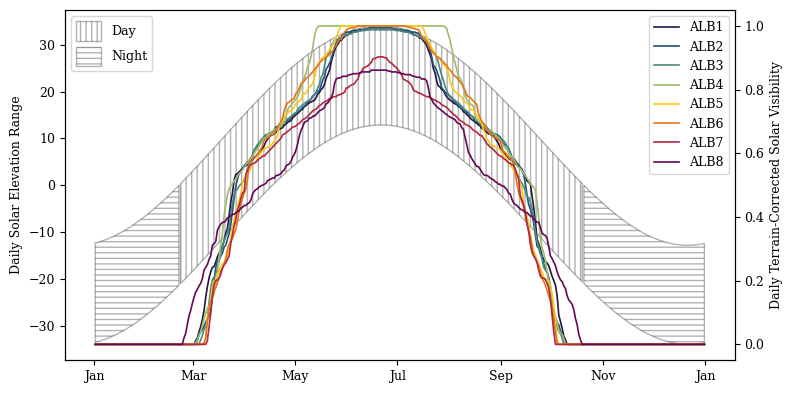

In [4]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(8, 4))

solar_above_horizon = np.where(np.max(solar_profiles["ALB1"]["alt_deg"], axis=1) > 0)
solar_below_horizon_0 = np.where(np.max(solar_profiles["ALB1"]["alt_deg"][:180], axis=1) < 0)
solar_below_horizon_1 = np.where(np.max(solar_profiles["ALB1"]["alt_deg"][180:], axis=1) < 0)

daily_times = solar_profiles["ALB1"]["times_utc"][:, 180]
solar_max_el = np.max(solar_profiles["ALB1"]["alt_deg"], axis=1)
solar_min_el = np.min(solar_profiles["ALB1"]["alt_deg"], axis=1)

ax.fill_between(
    daily_times[solar_above_horizon],
    solar_min_el[solar_above_horizon],
    solar_max_el[solar_above_horizon],
    label="Day",
    hatch="|||",
    fc="none",
    alpha=0.3,
)
ax.fill_between(
    daily_times[solar_below_horizon_0],
    solar_min_el[solar_below_horizon_0],
    solar_max_el[solar_below_horizon_0],
    label="Night",
    hatch="---",
    fc="none",
    alpha=0.3,
)
ax.fill_between(
    daily_times[180:][solar_below_horizon_1],
    solar_min_el[180:][solar_below_horizon_1],
    solar_max_el[180:][solar_below_horizon_1],
    hatch="---",
    fc="none",
    alpha=0.3,
)
plt.legend(loc="upper left", markerscale=2.8, handleheight=2)

ax.set_ylabel("Daily Solar Elevation Range")

colors = prd(np.linspace(0, 1, 8))
ax2 = ax.twinx()
for i, ant in enumerate(gps_coords.keys()):
    frac_illum = np.array([np.where(alt >= solar_profiles[ant]["hp"])[0].size / 360 for alt in solar_profiles[ant]["alt_deg"]])
    ax2.plot(daily_times, frac_illum, label=ant, color=colors[i])

ax2.legend(loc="upper right")

ax2.set_ylabel("Daily Terrain-Corrected Solar Visibility")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.tight_layout()
plt.show()

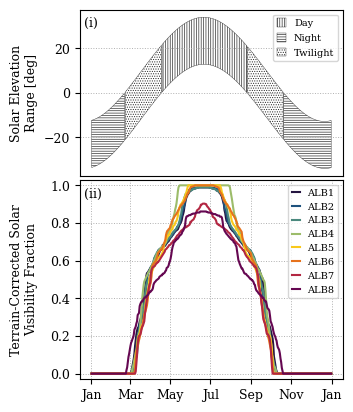

In [5]:
%matplotlib inline

plt.rcParams["hatch.linewidth"] = 0.5

# ------------------------------------------------------------------
# Figure setup
# ------------------------------------------------------------------
fig, (ax0, ax1) = plt.subplots(
    2,
    1,
    figsize=(3.4, 4.8),
    sharex=True,
    gridspec_kw={"height_ratios": [1.0, 1.2], "hspace": 0.02},
)

# ------------------------------------------------------------------
# Solar elevation envelope (top panel)
# ------------------------------------------------------------------
daily_times = solar_profiles["ALB1"]["times_utc"][:, 180]
solar_max_el = np.max(solar_profiles["ALB1"]["alt_deg"], axis=1)
solar_min_el = np.min(solar_profiles["ALB1"]["alt_deg"], axis=1)

is_night = solar_max_el < 0
is_dawn_dusk = (solar_min_el < 0) & (solar_max_el > 0)
is_day = solar_min_el > 0

ax0.fill_between(
    daily_times,
    solar_min_el,
    solar_max_el,
    where=is_day,
    label="Day",
    hatch="|||||||",
    fc="none",
    # edgecolor="0.65",
    linewidth=0.3,
    alpha=0.8,
)

ax0.fill_between(
    daily_times,
    solar_min_el,
    solar_max_el,
    where=is_night,
    label="Night",
    hatch="-------",
    fc="none",
    # edgecolor="0.65",
    linewidth=0.3,
    alpha=0.8,
)

ax0.fill_between(
    daily_times,
    solar_min_el,
    solar_max_el,
    where=is_dawn_dusk,
    label="Twilight",
    hatch=".......",
    fc="none",
    # edgecolor="0.65",
    linewidth=0.3,
    alpha=0.8,
)

ax0.set_ylabel("Solar Elevation\nRange [deg]")
ax0.legend(
    loc="upper right",
    fontsize=7,
    frameon=True,
    handleheight=1,
    handlelength=1,
)

ax0.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax0.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax0.xaxis.set_visible(False)

# ------------------------------------------------------------------
# Terrain-corrected solar visibility (bottom panel)
# ------------------------------------------------------------------
colors = prd(np.linspace(0, 1, 8))

for i, ant in enumerate(gps_coords.keys()):
    frac_illum = np.array([np.count_nonzero(alt >= solar_profiles[ant]["hp"]) / 360 for alt in solar_profiles[ant]["alt_deg"]])

    ax1.plot(
        daily_times,
        frac_illum,
        label=ant,
        color=colors[i],
        lw=1.5,
    )

ax1.set_ylabel("Terrain-Corrected Solar\nVisibility Fraction")
ax1.set_ylim(-0.03, 1.03)

ax1.legend(
    loc="upper right",
    fontsize=7,
    frameon=True,
    handlelength=0.8,
)

# ------------------------------------------------------------------
# Shared x-axis formatting
# ------------------------------------------------------------------
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

# ------------------------------------------------------------------
# Align y-labels and add panel labels
# ------------------------------------------------------------------
fig.align_ylabels([ax0, ax1])

panel_labels = ["(i)", "(ii)"]
for i, ax in enumerate([ax0, ax1]):
    ax.text(
        0.016,
        0.96,
        panel_labels[i],
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        color="k",
    )

    ax.grid(ls=":", lw=0.7, alpha=1)

fig.savefig("paper/solar_elevation.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

In [6]:
zarr_path = "/Volumes/specscout/zarr/202407/MARS3_202407.zarr/"

pipe_stokes_i_db = (
    PreprocessPipeline(input_space="linear")
    .with_metadata(
        zarr_path=zarr_path,
        notes="Stokes I from chan 0/1, then safe_db",
    )
    .add(step_stokes_i(name="stokes_i"))
    .add(step_safe_db(name="safe_db"))
)

In [7]:
# Leap seconds effective from these UTC instants.
# For example, the leap second inserted on 2016-12-31 becomes effective at
# 2017-01-01 00:00:00 UTC.
_LEAP_SECOND_EFFECTIVE_UTC = pd.DatetimeIndex(
    [
        "2006-01-01T00:00:00Z",  # after 2005-12-31 leap second
        "2009-01-01T00:00:00Z",  # after 2008-12-31
        "2012-07-01T00:00:00Z",  # after 2012-06-30
        "2015-07-01T00:00:00Z",  # after 2015-06-30
        "2017-01-01T00:00:00Z",  # after 2016-12-31
    ],
    tz="UTC",
)


def _count_leap_seconds_since_base(naive_times_utc: pd.DatetimeIndex) -> np.ndarray:
    """
    Count leap seconds since 2000-01-01 12:00:00 UTC for each timestamp.

    Parameters
    ----------
    naive_times_utc
        Timestamps formed from base_time + elapsed_seconds, before leap-second
        correction.

    Returns
    -------
    numpy.ndarray
        Integer leap-second counts, one per timestamp.
    """
    t_ns = naive_times_utc.view("i8")
    leap_ns = _LEAP_SECOND_EFFECTIVE_UTC.view("i8")
    return np.searchsorted(leap_ns, t_ns, side="right").astype(np.int64)


def _iter_days(start: pd.Timestamp, stop: pd.Timestamp) -> Iterable[pd.Timestamp]:
    """Yield UTC dates touched by [start, stop)."""
    day0 = start.floor("D")
    day1 = stop.floor("D")
    for day in pd.date_range(day0, day1, freq="D", tz="UTC"):
        yield day


def _goes_files_for_range(root: str | Path, *, start: str | pd.Timestamp, stop: str | pd.Timestamp) -> list[Path]:
    """
    Return local GOES XRS files overlapping the requested UTC range.

    Expects files named:
        root/YYYY/sci_xrsf-l2-flx1s_g18_dYYYYMMDD_v2-2-1.nc
    """
    root = Path(root)

    start_ts = pd.Timestamp(start, tz="UTC") if not isinstance(start, pd.Timestamp) else start.tz_convert("UTC")
    stop_ts = pd.Timestamp(stop, tz="UTC") if not isinstance(stop, pd.Timestamp) else stop.tz_convert("UTC")

    if not (start_ts < stop_ts):
        raise ValueError("start must be earlier than stop.")

    files: list[Path] = []
    for day in _iter_days(start_ts, stop_ts):
        year_dir = root / f"{day.year:04d}"
        pattern = f"sci_xrsf-l2-flx1s_g18_d{day.strftime('%Y%m%d')}_v*.nc"
        files.extend(sorted(year_dir.glob(pattern)))

    return sorted(files)


def _decode_goes_time_seconds(time_seconds: np.ndarray) -> pd.DatetimeIndex:
    """
    Decode GOES XRS time to UTC, including leap-second correction.

    The raw variable is seconds since 2000-01-01 12:00:00 UTC, computed without
    leap seconds. We first form naive UTC-like timestamps, then add the number
    of leap seconds that have occurred since the base time.
    """
    base = pd.Timestamp("2000-01-01T12:00:00Z")
    naive = pd.to_datetime(time_seconds, unit="s", origin=base.tz_localize(None), utc=True)
    n_leaps = _count_leap_seconds_since_base(naive)
    corrected = naive + pd.to_timedelta(n_leaps, unit="s")
    return pd.DatetimeIndex(corrected, name="time")


def load_goes18_xrs_1s(
    root: str | Path,
    *,
    start: str | pd.Timestamp,
    stop: str | pd.Timestamp,
    short_var: str = "xrsa_flux",
    long_var: str = "xrsb_flux",
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Load local GOES-18 XRS 1 s data for a UTC interval.

    Parameters
    ----------
    root
        Root directory containing files organized as:
            root/YYYY/sci_xrsf-l2-flx1s_g18_dYYYYMMDD_v*.nc
    start, stop
        UTC bounds. `stop` is treated as exclusive.
    short_var
        Variable name for the short XRS channel.
    long_var
        Variable name for the long XRS channel.

    Returns
    -------
    times, short_xrs, long_xrs
        Arrays ready for direct comparison with ALBATROS:
        - times: numpy datetime64[ns] array (UTC)
        - short_xrs: short-channel flux
        - long_xrs: long-channel flux
    """
    start_ts = pd.Timestamp(start, tz="UTC") if not isinstance(start, pd.Timestamp) else start.tz_convert("UTC")
    stop_ts = pd.Timestamp(stop, tz="UTC") if not isinstance(stop, pd.Timestamp) else stop.tz_convert("UTC")

    files = _goes_files_for_range(root, start=start_ts, stop=stop_ts)
    if not files:
        raise FileNotFoundError(f"No GOES-18 XRS files found under {root!r} for {start_ts} to {stop_ts}.")

    times_all: list[pd.DatetimeIndex] = []
    short_all: list[np.ndarray] = []
    long_all: list[np.ndarray] = []

    for path in files:
        with xr.open_dataset(path, decode_times=False) as ds:
            if "time" not in ds.variables:
                raise KeyError(f"{path.name} is missing variable 'time'.")
            if short_var not in ds.variables:
                raise KeyError(f"{path.name} is missing variable {short_var!r}.")
            if long_var not in ds.variables:
                raise KeyError(f"{path.name} is missing variable {long_var!r}.")

            t = _decode_goes_time_seconds(ds["time"].values)
            times_all.append(t)
            short_all.append(np.asarray(ds[short_var].values))
            long_all.append(np.asarray(ds[long_var].values))

    times = pd.DatetimeIndex(np.concatenate([t.values for t in times_all]), tz="UTC")
    short_xrs = np.concatenate(short_all)
    long_xrs = np.concatenate(long_all)

    order = np.argsort(times.view("i8"))
    times = times[order]
    short_xrs = short_xrs[order]
    long_xrs = long_xrs[order]

    keep = (times >= start_ts) & (times < stop_ts)
    times = times[keep]
    short_xrs = short_xrs[keep]
    long_xrs = long_xrs[keep]

    return times.to_numpy(), short_xrs, long_xrs

In [8]:
def _normalize_series(x: np.ndarray) -> np.ndarray:
    """
    Normalize a 1D array to [0, 1], preserving NaNs.
    """
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)

    finite = np.isfinite(x)
    if not np.any(finite):
        return out

    xmin = np.nanmin(x[finite])
    xmax = np.nanmax(x[finite])

    if np.isclose(xmax, xmin):
        out[finite] = 0.5
        return out

    out[finite] = (x[finite] - xmin) / (xmax - xmin)
    return out


def plot_time_range_with_lightcurves(
    zarr_path: str | Path,
    *,
    start_utc: str | pd.Timestamp,
    stop_utc: str | pd.Timestamp,
    chans: int | tuple[int, ...] | list[int],
    pipe=None,
    goes_root: str | Path | None = None,
    include_goes: bool = True,
    goes_loader=load_goes18_xrs_1s,
    cmap="viridis",
    clim_percentiles: tuple[float, float] = (0.1, 99.9),
    vlims: tuple[float, float] | None = None,
    normalize_lightcurves: bool = True,
    alb_reduce: str = "mean",
    figsize: tuple[float, float] = (7, 4.8),
    title: str | None = None,
) -> tuple[plt.Figure, np.ndarray]:
    """
    Plot a specscout time-range waterfall with a light-curve panel above it.

    Top panel
    ---------
    - ALBATROS light curve derived from the plotted waterfall
    - GOES-18 XRS longwave light curve over the same UTC range

    Bottom panel
    ------------
    - Time-frequency waterfall from `read_time_range(...)`

    Parameters
    ----------
    zarr_path
        Path to the specscout Zarr store.
    start_utc, stop_utc
        UTC bounds accepted by `read_time_range(...)`.
    chans
        Raw cube channel selection.
    pipe
        Optional preprocessing pipeline applied after reading.
    goes_root
        Root directory containing local GOES-18 XRS 1 s files, organized as
        `root/YYYY/sci_xrsf-l2-flx1s_g18_dYYYYMMDD_v*.nc`.
    include_goes
        If True, try to load and plot GOES longwave data.
    goes_loader
        Callable with the API of `load_goes18_xrs_1s(...)`.
    cmap
        Colormap for the waterfall.
    clim_percentiles
        Percentiles used for dynamic waterfall scaling when `vlims` is None.
    vlims
        Optional fixed color limits for the waterfall.
    normalize_lightcurves
        If True, normalize ALBATROS and GOES curves independently to [0, 1].
    alb_reduce
        Frequency reduction used to form the ALBATROS light curve.
        Supported values are `"mean"`, `"median"`, and `"sum"`.
    figsize
        Figure size in inches.
    title
        Optional figure title.

    Returns
    -------
    fig, axs
        Matplotlib figure and array of axes `[ax_top, ax_bottom]`.
    """
    data_tf, times, _meta = read_time_range(
        zarr_path,
        start_utc=start_utc,
        stop_utc=stop_utc,
        chans=chans,
        pipe=pipe,
    )

    times = pd.to_datetime(times, utc=True)

    fig, axs = plt.subplots(
        2,
        1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={"height_ratios": [1, 4], "hspace": 0.03},
    )
    ax_top, ax_bot = axs

    if data_tf.size == 0 or len(times) == 0:
        ax_top.text(0.5, 0.5, "No data in requested time range", ha="center", va="center")
        ax_top.set_axis_off()
        ax_bot.set_axis_off()
        return fig, axs

    data_tf = np.asarray(data_tf)
    if data_tf.ndim != 2:
        raise ValueError(f"Expected plotted data with shape (T, F) after pipe application, got {data_tf.shape}.")

    if len(times) < 2:
        raise ValueError("Need at least 2 time samples to build a waterfall plot.")

    # ------------------------------------------------------------------
    # ALBATROS light curve from the plotted waterfall
    # ------------------------------------------------------------------
    if alb_reduce == "mean":
        alb_lc = np.nanmean(data_tf, axis=1)
    elif alb_reduce == "median":
        alb_lc = np.nanmedian(data_tf, axis=1)
    elif alb_reduce == "sum":
        alb_lc = np.nansum(data_tf, axis=1)
    else:
        raise ValueError("alb_reduce must be one of {'mean', 'median', 'sum'}.")

    # ------------------------------------------------------------------
    # GOES longwave light curve for the same interval
    # ------------------------------------------------------------------
    goes_times: pd.DatetimeIndex | None = None
    goes_long: np.ndarray | None = None

    if include_goes:
        if goes_root is None:
            raise ValueError("goes_root must be provided when include_goes=True.")

        try:
            # Small +1 s pad on stop because the GOES loader uses an exclusive bound.
            t_goes, _short_goes, long_goes = goes_loader(
                goes_root,
                start=times[0],
                stop=times[-1] + pd.Timedelta(seconds=1),
            )
            goes_times = pd.to_datetime(t_goes, utc=True)
            goes_long = np.asarray(long_goes, dtype=float)

            # Final explicit clip to plotted interval
            keep_goes = (goes_times >= times[0]) & (goes_times <= times[-1])
            goes_times = goes_times[keep_goes]
            goes_long = goes_long[keep_goes]

            if len(goes_times) == 0:
                goes_times = None
                goes_long = None

        except FileNotFoundError:
            warnings.warn(
                "No GOES-18 XRS files found for the requested interval; plotting ALBATROS only.",
                RuntimeWarning,
                stacklevel=2,
            )
        except Exception as exc:
            warnings.warn(
                f"Failed to load GOES-18 XRS data ({exc}); plotting ALBATROS only.",
                RuntimeWarning,
                stacklevel=2,
            )

    # ------------------------------------------------------------------
    # Normalize light curves if desired
    # ------------------------------------------------------------------
    if normalize_lightcurves:
        alb_plot = _normalize_series(alb_lc)
        goes_plot = _normalize_series(goes_long) if goes_long is not None else None
        top_ylabel = "Normalized amplitude"
    else:
        alb_plot = alb_lc
        goes_plot = goes_long
        top_ylabel = "Amplitude"

    # ------------------------------------------------------------------
    # Top panel: light curves
    # ------------------------------------------------------------------
    ax_top.plot(times, alb_plot, lw=1.2, label="ALBATROS [1–125 MHz]", drawstyle="steps-mid", color="k")
    if goes_times is not None and goes_plot is not None:
        ax_top.plot(goes_times, goes_plot, lw=1.2, label="GOES X-Ray [1–8 Å]", drawstyle="steps-mid", color="k", ls="--")

    # ax_top.set_ylabel(top_ylabel)
    ax_top.grid(ls=":", alpha=0.4)
    ax_top.legend(loc="upper left", fontsize=8)
    # ax_top.set_ylabel("Normalised Flux")
    ax_top.set_ylabel("Normalized\nFlux")
    ax_top.xaxis.set_visible(False)

    # ------------------------------------------------------------------
    # Bottom panel: waterfall
    # ------------------------------------------------------------------
    cube, attrs, _time_axis = open_cube(zarr_path)
    freqs_all, _x_label = freq_axis_from_attrs(attrs, cube.shape[1])
    freqs = np.asarray(freqs_all[: data_tf.shape[1]], dtype=float)

    t_num = mdates.date2num(times.to_pydatetime())
    dt_days = np.median(np.diff(t_num))
    x_edges = np.concatenate(
        [
            [t_num[0] - 0.5 * dt_days],
            0.5 * (t_num[:-1] + t_num[1:]),
            [t_num[-1] + 0.5 * dt_days],
        ]
    )

    y_edges = np.concatenate(
        [
            [freqs[0] - 0.5 * (freqs[1] - freqs[0])],
            0.5 * (freqs[:-1] + freqs[1:]),
            [freqs[-1] + 0.5 * (freqs[-1] - freqs[-2])],
        ]
    )

    mesh = ax_bot.pcolormesh(x_edges, y_edges, data_tf.T, shading="auto", cmap=cmap, rasterized=True)

    if vlims is not None:
        mesh.set_clim(*vlims)
    else:
        vmin = float(np.nanpercentile(data_tf, clim_percentiles[0]))
        vmax = float(np.nanpercentile(data_tf, clim_percentiles[1]))
        mesh.set_clim(vmin, vmax)

    ax_bot.set_ylabel("Frequency [MHz]")
    # ax_bot.set_yticks([0, 25, 50, 75, 100, 125])
    ax_bot.set_xlabel("UTC Time")

    divider = make_axes_locatable(ax_bot)

    # Smaller pad pulls the colorbar closer to the top panel.
    cax = divider.append_axes("top", size="7%", pad=0.05)
    cbar = fig.colorbar(
        mesh,
        cax=cax,
        orientation="horizontal",
    )

    # Put ticks and label inside the colorbar.
    cbar.ax.xaxis.set_ticks_position("top")
    cbar.ax.xaxis.set_label_position("top")

    # Tick labels inside the colorbar.
    cbar.ax.tick_params(
        axis="x",
        which="both",
        direction="in",
        length=3,  # shorter tick marks
        width=0.8,
        pad=-11,  # negative pad moves labels into the bar
        labelsize=8,
        color="#222222",
        labelcolor="#222222",
    )
    cbar.set_ticks([80, 90, 100])

    cbar.ax.text(
        0.084,
        0.49,
        "Power [dB]",
        transform=cbar.ax.transAxes,
        ha="center",
        va="center",
        color="whitesmoke",
        fontsize=9,
    )

    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    ax_bot.xaxis.set_major_locator(locator)
    ax_bot.xaxis.set_major_formatter(formatter)

    return fig, axs

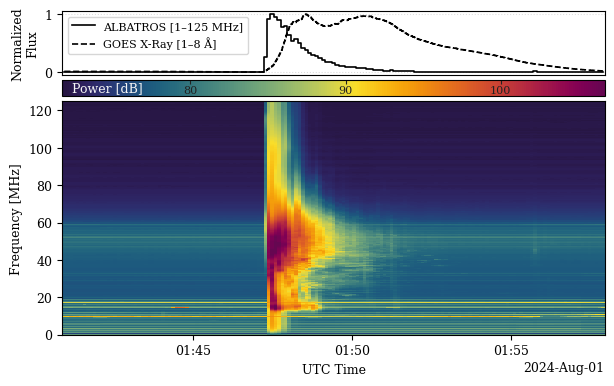

In [9]:
%matplotlib inline
fig, axs = plot_time_range_with_lightcurves(
    zarr_path=zarr_path,
    start_utc="20240801_014100",
    stop_utc="20240801_015800",
    chans=(0, 1),
    pipe=pipe_stokes_i_db,
    goes_root="/Volumes/specscout/goes18_xrs_1s/",
    cmap=prd,
    clim_percentiles=(0.1, 99.9),
    normalize_lightcurves=True,
    figsize=(7, 4.2),
)

fig.savefig("paper/solar_flare_goes_coincidence.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

In [28]:
def _plot_waterfall_grid(
    data: np.ndarray,
    *,
    freqs: np.ndarray,
    frame_meta: FrameMeta | None = None,
    times: pd.DatetimeIndex | None = None,
    channel_labels: Sequence[str] | None = None,
    cmap=cmr.pride,
    clim_percentiles: tuple[float, float] = (1.0, 99.0),
    vlims=None,
    cbar_units: str | Sequence[str] = "linear",
    center_zero: bool | Sequence[bool] = False,
    figsize: tuple[float, float] = (8.5, 5.5),
    title: str | None = None,
) -> tuple[plt.Figure, np.ndarray]:
    """
    Generic waterfall plotting for either one panel or a panel grid.

    Parameters
    ----------
    data
        Array of shape ``(T, F)`` or ``(T, F, C)``.
    freqs
        Frequency axis values.
    frame_meta
        Required when ``x_mode="frame"``.
    times
        Required when ``x_mode="timerange"``.
    channel_labels
        Optional labels for each panel.
    cmap
        Either a single colormap or a sequence of length `n_panels`.
    clim_percentiles
        Percentiles used when `vlims` is None.
    vlims
        Either None, a single `(vmin, vmax)` pair, or a sequence of per-panel
        `(vmin, vmax)` pairs.
    cbar_units
        Either a single colorbar label or a sequence of per-panel labels.
    center_zero
        Either a single bool or a sequence of per-panel bools. When True for a
        panel, color limits are chosen symmetrically around zero unless
        overridden by an explicit `vlims`.
    """
    arr = np.asarray(data)

    _nt, nfreq, n_panels = arr.shape

    cmaps = _normalize_panel_arg(cmap, n_panels=n_panels, name="cmap")
    vlims_list = _normalize_panel_arg(vlims, n_panels=n_panels, name="vlims")
    units_list = _normalize_panel_arg(
        cbar_units,
        n_panels=n_panels,
        name="cbar_units",
    )
    center_zero_list = _normalize_panel_arg(
        center_zero,
        n_panels=n_panels,
        name="center_zero",
    )

    # nrows, ncols = _panel_layout(n_panels)
    nrows, ncols = 4, 1
    fig, axs = plt.subplots(nrows, ncols, figsize=(figsize[0], figsize[1]), sharex=True, gridspec_kw={"hspace": 0.03})
    axs_flat = axs.ravel()

    if times is None or len(times) < 2:
        raise ValueError("times must be provided with at least 2 samples when x_mode='timerange'.")
    x_edges = _time_edges_from_datetimes(times)
    y_edges = np.concatenate(
        [
            [freqs[0] - 0.5 * (freqs[1] - freqs[0])],
            0.5 * (freqs[:-1] + freqs[1:]),
            [freqs[-1] + 0.5 * (freqs[-1] - freqs[-2])],
        ]
    )

    cbars = []
    for j in range(n_panels):
        ax = axs_flat[j]
        img = arr[:, :, j]
        panel_label = str(channel_labels[j])
        panel_cmap = cmaps[j]
        panel_vlims = vlims_list[j]
        panel_units = units_list[j]
        panel_center_zero = bool(center_zero_list[j])

        im = ax.pcolormesh(x_edges, y_edges, img.T, shading="auto", cmap=panel_cmap, rasterized=True)
        if j == 3:
            ax.set_xlabel("UTC time")
        # ax.set_ylabel("Frequency [MHz]")
        if j != 3:
            ax.xaxis.set_visible(False)

        locator = mdates.AutoDateLocator()
        formatter = mdates.ConciseDateFormatter(locator)
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(formatter)

        if panel_center_zero:
            vmin, vmax = _centered_vlims_for_image(
                img,
                clim_percentiles=clim_percentiles,
                vlims=panel_vlims,
            )
        else:
            vmin, vmax = _vlims_for_image(
                img,
                clim_percentiles=clim_percentiles,
                vlims=panel_vlims,
            )

        im.set_clim(vmin, vmax)
        # ax.set_title(panel_label)

        cbar = fig.colorbar(im, ax=ax, fraction=0.3, pad=0.01)
        cbar.set_label("" if panel_units is None else str(panel_units))
        cbars.append(cbar)

        panel_labels = ["(i)", "(ii)", "(iii)", "(iv)"]
        ax.text(
            0.012,  # x-position in axes coordinates
            0.96,  # y-position in axes coordinates
            panel_labels[j],
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            # fontweight="bold",
            color="w",  # use "k" if preferred
            bbox=dict(
                facecolor="k",
                alpha=0.3,
                edgecolor="none",
                pad=1.5,
            ),
        )

    for cbar in cbars:
        cbar.ax.yaxis.set_label_coords(7.7, 0.5)

    for j in range(n_panels, len(axs_flat)):
        axs_flat[j].set_axis_off()

    fig.supylabel("Frequency [MHz]", x=0.07, fontsize=9)

    return fig, axs


def plot_time_range_stokes_fractional(
    zarr_path: str | Path,
    *,
    start_utc: str | pd.Timestamp,
    stop_utc: str | pd.Timestamp,
    chans: int | Sequence[int],
    pipe: PreprocessPipeline | None = None,
    clim_percentiles: tuple[float, float] = (1.0, 99.0),
    vlims=None,
    figsize: tuple[float, float] = (11.0, 7.5),
    title: str | None = None,
) -> tuple[plt.Figure, np.ndarray]:
    """
    Plot a 4-panel Stokes diagnostic quicklook over a contiguous time range.

    Expected pipeline output shape is ``(T, F, 4)`` with channels ordered as:
    ``(stokes_I, stokes_Q, stokes_U, stokes_V)``.

    Expects linear Stokes IQUV inputs
    """

    _reject_db_recipe_pipe(
        pipe,
        func_name="plot_frame_instrumental_quicklook",
        expected="linear instrumental inputs",
    )

    data, times, _meta = read_time_range(
        zarr_path,
        start_utc=start_utc,
        stop_utc=stop_utc,
        chans=chans,
        pipe=pipe,
    )

    if data.size == 0 or len(times) == 0:
        fig, ax = plt.subplots(figsize=figsize)
        ax.text(0.5, 0.5, "No data in requested time range", ha="center", va="center")
        ax.set_axis_off()
        return fig, np.asarray([ax])

    quick, labels, cmaps, units, recipe_vlims, center_zero = _build_stokes_fractional_quicklook(data)

    use_vlims = recipe_vlims if vlims is None else vlims

    cube, attrs, _time_axis = open_cube(zarr_path)
    freqs_all, _ = freq_axis_from_attrs(attrs, cube.shape[1])
    freqs = np.asarray(freqs_all[: quick.shape[1]], dtype=float)

    return _plot_waterfall_grid(
        quick,
        freqs=freqs,
        times=pd.to_datetime(times, utc=True),
        channel_labels=labels,
        cmap=cmaps,
        clim_percentiles=clim_percentiles,
        # vlims=use_vlims,
        # cbar_units=units,
        vlims=[(71, 103), (-0.98, 0.98), (-0.05, 0.05), (-0.12, 0.12)],
        cbar_units=["Stokes I [dB]", "Stokes Q/I", "Stokes U/I", "Stokes V/I"],
        center_zero=center_zero,
        figsize=figsize,
        title=title,
    )

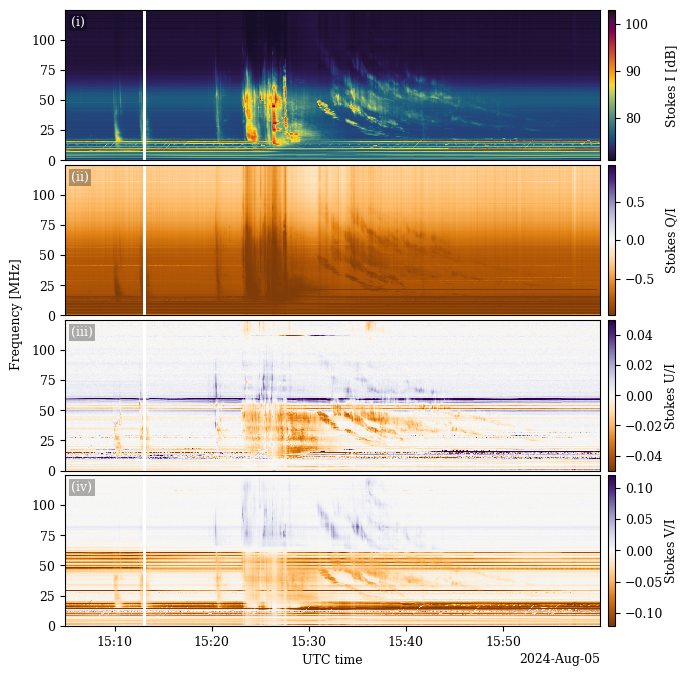

In [29]:
%matplotlib inline

pipe_stokes_iquv = PreprocessPipeline().add(step_stokes_iquv())

fig, ax = plot_time_range_stokes_fractional(
    zarr_path=zarr_path,
    start_utc="20240805_150500",
    stop_utc="20240805_160000",
    chans=(0, 1, 2, 3),
    pipe=pipe_stokes_iquv,
    clim_percentiles=(0.1, 99.9),
    figsize=(10, 8),
)

# plt.tight_layout()
fig.savefig("paper/solar_full_stokes.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

In [20]:
zarr_paths = {
    "ALB1": "/Volumes/specscout/zarr/202507/MARS1_202507.zarr",
    "ALB2": "/Volumes/specscout/zarr/202507/MARS2_202507.zarr",
    "ALB3": "/Volumes/specscout/zarr/202507/MARS3_202507.zarr",
    "ALB4": "/Volumes/specscout/zarr/202507/MARS4_202507.zarr",
    "ALB5": "/Volumes/specscout/zarr/202507/MARS5_202507.zarr",
    "ALB6": "/Volumes/specscout/zarr/202507/MARS6_202507.zarr",
    "ALB7": "/Volumes/specscout/zarr/202507/MARS7_202507.zarr",
    "ALB8": "/Volumes/specscout/zarr/202507/MARS8_202507.zarr",
}

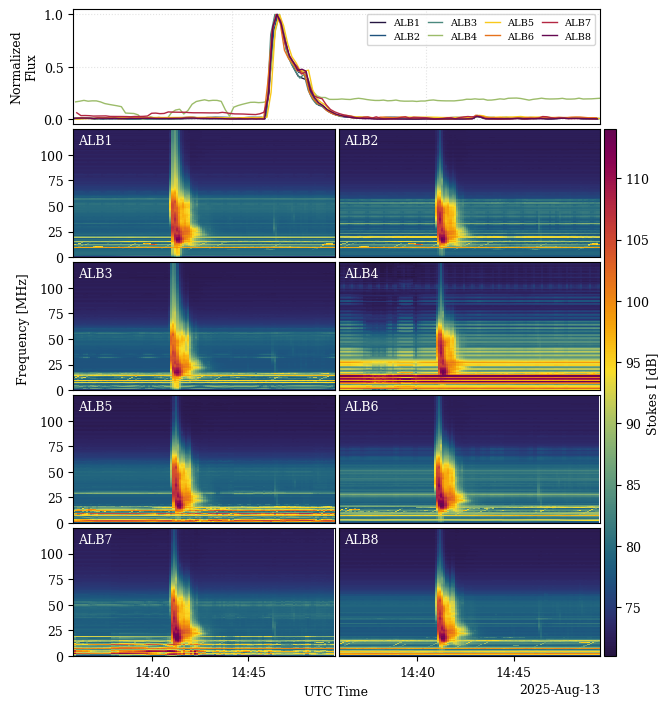

In [21]:
%matplotlib inline

fig = plt.figure(figsize=(7, 8.4))

gs = fig.add_gridspec(
    5,
    3,
    width_ratios=[1, 1, 0.045],
    height_ratios=[0.9, 1, 1, 1, 1],
    hspace=0.04,
    wspace=0.02,
)

ax_lc = fig.add_subplot(gs[0, :2])

axs = []
for r in range(1, 5):
    for c in range(2):
        axs.append(fig.add_subplot(gs[r, c], sharex=ax_lc, sharey=axs[0] if axs else None))

cax = fig.add_subplot(gs[1:, 2])

vmin, vmax = 71, 114
meshes = []
lightcurves = {}

for i, (st, zp) in enumerate(zarr_paths.items()):
    ax = axs[i]

    arr, times, meta = read_time_range(
        zp,
        start_utc="20250813_143600",
        stop_utc="20250813_144930",
        chans=(0, 1),
        pipe=pipe_stokes_i_db,
    )

    arr = np.asarray(arr)
    times = pd.to_datetime(times, utc=True)

    cube, attrs, _time_axis = open_cube(zp)
    freqs_all, _x_label = freq_axis_from_attrs(attrs, cube.shape[1])
    freqs = np.asarray(freqs_all[: arr.shape[1]], dtype=float)

    t_num = mdates.date2num(times.to_pydatetime())

    dt_days = np.median(np.diff(t_num))
    x_edges = np.concatenate(
        [
            [t_num[0] - 0.5 * dt_days],
            0.5 * (t_num[:-1] + t_num[1:]),
            [t_num[-1] + 0.5 * dt_days],
        ]
    )

    df = np.median(np.diff(freqs))
    y_edges = np.concatenate(
        [
            [freqs[0] - 0.5 * df],
            0.5 * (freqs[:-1] + freqs[1:]),
            [freqs[-1] + 0.5 * df],
        ]
    )

    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        arr.T,
        cmap=prd,
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        rasterized=True,
    )
    meshes.append(mesh)

    # Station light curve: frequency-averaged Stokes I
    lc = np.nanmean(arr, axis=1)
    lc = (lc - np.nanmin(lc)) / (np.nanmax(lc) - np.nanmin(lc))
    lightcurves[st] = (times, lc)

    ax.text(
        0.02,
        0.96,
        st,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        color="white",
    )

    # ax.tick_params(direction="in", top=True, right=True)

    if i not in [6, 7]:
        ax.xaxis.set_visible(False)
    if i not in [0, 2, 4, 6]:
        ax.yaxis.set_visible(False)

    if i not in [6, 7]:
        ax.tick_params(labelbottom=False)

    if i not in [0, 2, 4, 6]:
        ax.tick_params(labelleft=False)

# ------------------------------------------------------------------
# Top panel: normalized light curves
# ------------------------------------------------------------------
colors = prd(np.linspace(0, 1, 8))
j = 0
for st, (t, lc) in lightcurves.items():
    ax_lc.plot(t, lc, lw=1.0, label=st, color=colors[j])
    j += 1

ax_lc.set_ylabel("Normalized\nFlux")
ax_lc.set_ylim(-0.05, 1.05)
ax_lc.grid(ls=":", alpha=0.35)
ax_lc.tick_params(bottom=False, labelbottom=False)

ax_lc.legend(
    loc="upper right",
    ncol=4,
    fontsize=7,
    frameon=True,
    columnspacing=0.8,
    handlelength=1.5,
)

# ------------------------------------------------------------------
# Shared formatting
# ------------------------------------------------------------------
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)

for ax in [ax_lc, *axs]:
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)

axs[6].xaxis.get_offset_text().set_visible(False)

fig.supxlabel("UTC Time", y=0.06, fontsize=9)
fig.supylabel("Frequency [MHz]", x=0.045, fontsize=9)

# ------------------------------------------------------------------
# Full-height colorbar spanning waterfall panels
# ------------------------------------------------------------------
if meshes:
    cbar = fig.colorbar(meshes[0], cax=cax, orientation="vertical")
    cbar.set_label("Stokes I [dB]", labelpad=-2)

fig.savefig("paper/solar_flare_all_stations.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

In [22]:
def plot_cross_correlation(
    times: pd.DatetimeIndex,
    alb_flux: np.ndarray,
    goes_flux: np.ndarray,
    *,
    max_lag_seconds: float = 600,
    normalize: bool = True,
    figsize: tuple[float, float] = (3.4, 2.8),
) -> tuple[plt.Figure, plt.Axes]:
    """
    Plot the normalized cross-correlation between ALBATROS and GOES.

    Parameters
    ----------
    times
        Common time grid for both series.
    alb_flux
        ALBATROS light curve.
    goes_flux
        GOES light curve sampled on the same timestamps.
    max_lag_seconds
        Maximum lag to display in seconds.
    normalize
        If True, subtract mean and divide by standard deviation before
        computing the cross-correlation.
    figsize
        Matplotlib figure size in inches.

    Returns
    -------
    fig, ax
        Matplotlib figure and axes.
    """
    times = pd.to_datetime(times, utc=True)
    alb_flux = np.asarray(alb_flux, dtype=float)
    goes_flux = np.asarray(goes_flux, dtype=float)

    mask = np.isfinite(alb_flux) & np.isfinite(goes_flux)
    alb = alb_flux[mask]
    goes = goes_flux[mask]
    t = times[mask]

    if len(alb) < 3:
        raise ValueError("Need at least 3 overlapping samples.")

    # Sampling cadence [s]
    dt = np.median(np.diff(t.view("int64"))) / 1e9

    if normalize:
        alb = (alb - np.mean(alb)) / np.std(alb)
        goes = (goes - np.mean(goes)) / np.std(goes)

    # Full cross-correlation
    corr = correlate(alb, goes, mode="full")
    lags = correlation_lags(len(alb), len(goes), mode="full")
    lags_seconds = lags * dt

    # Normalize so peak lies between -1 and 1
    corr = corr / len(alb)

    # Restrict lag range
    keep = np.abs(lags_seconds) <= max_lag_seconds
    lags_seconds = lags_seconds[keep]
    corr = corr[keep]

    # Peak correlation
    i_peak = np.argmax(corr)
    lag_peak = lags_seconds[i_peak]
    corr_peak = corr[i_peak]

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.grid(ls=":", lw=0.7, alpha=0.7)

    ax.plot(lags_seconds, corr, color="k", lw=1.5, zorder=42)
    ax.axvline(0, color=cmr.pride(0.1), ls=":", lw=0.7, zorder=7)
    ax.axhline(0, color=cmr.pride(0.1), ls=":", lw=0.7, zorder=7)
    ax.axvline(lag_peak, color=cmr.pride(0.77), ls="-.", lw=1.5, zorder=44)
    ax.plot(lag_peak, corr_peak, "o", color=cmr.pride(0.77), ms=7, zorder=46)

    ax.set_xlabel("Lag [s]")
    ax.set_ylabel("Cross-correlation")
    ax.set_xlim(-max_lag_seconds, max_lag_seconds)
    ax.set_ylim(-1.05, 1.05)

    # Sign convention:
    if lag_peak < 0:
        lag_text = f"Radio leads X-rays by {abs(lag_peak):.0f}s"
    elif lag_peak > 0:
        lag_text = f"Radio lags X-rays by {abs(lag_peak):.0f}s"
    else:
        lag_text = "No measurable lag"

    ax.text(
        0.03,
        0.96,
        f"Peak correlation = {corr_peak:.2f}\n{lag_text}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8,
        bbox=dict(facecolor="white", edgecolor="0.8", alpha=1),
        zorder=49
    )

    ax.set_xticks([-600, -300, 0, 300, 600])
    ax.set_ylim([-0.3, 0.98])

    fig.tight_layout()
    return fig, ax

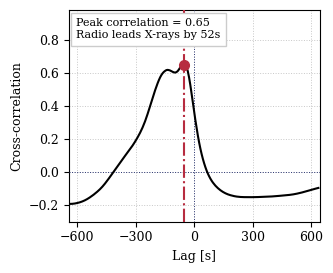

In [23]:
# Load ALBATROS dynamic spectrum
arr, times, meta = read_time_range(
    zarr_path,
    start_utc="20240801_013000",
    stop_utc="20240801_020000",
    chans=(0, 1),
    pipe=pipe_stokes_i_db,
)

times = pd.to_datetime(times, utc=True)
arr = np.asarray(arr)

# Integrated ALBATROS light curve
alb_lc = np.nanmean(arr, axis=1)

# Load GOES
goes_times, goes_short, goes_long = load_goes18_xrs_1s(
    "/Volumes/specscout/goes18_xrs_1s/",
    start=times[0],
    stop=times[-1] + pd.Timedelta(seconds=1),
)

goes_times = pd.to_datetime(goes_times, utc=True)
goes_long = np.asarray(goes_long, dtype=float)

# Interpolate GOES onto ALBATROS timestamps
goes_interp = np.interp(
    times.view("int64"),
    goes_times.view("int64"),
    goes_long,
)

fig, ax = plot_cross_correlation(
    times,
    alb_lc,
    goes_interp,
    max_lag_seconds=644,
)

plt.tight_layout()
fig.savefig("paper/radio_xray_correlation.pdf", bbox_inches="tight", pad_inches=0.02)